# GEOS Scaling Analysis (KGD timing benchmark)

Generates the strong/weak scaling figure used in the thesis (Chapter 2,
Computational Performance and Scalability) from `strong.csv` and `weak.csv`.

- **Strong scaling:** fixed $60\times100\times2$ (12,000-element) KGD timing deck,
  1--64 MPI ranks on a single Perlmutter CPU node, partitioned along $y$
  (`strong_scaling_kgd.sh`).
- **Weak scaling:** deck regenerated per rank count $N$ with the domain stretched
  along $y$ ($n_y = 100N$), so every rank owns a constant $60\times100\times2$ block
  (`weak_scaling_kgd.sh`).

Only rows with `complete = True` are used; times are `run_time_s` (solver wall
time, initialization excluded), averaged over repetitions.

In [6]:
import csv
import numpy as np
import matplotlib.pyplot as plt

BASE = "../data"   # packaged copies of strong.csv / weak.csv (originals in GEOS/NERSC/scalability_tests)

BASE_FIG_DIR = "../figures/"

In [7]:
def load(path):
    rows = [r for r in csv.DictReader(open(path))
            if r["complete"] == "True" and float(r["run_time_s"]) > 0]
    out = {}
    for r in rows:
        out.setdefault(int(r["num_ranks"]), []).append(float(r["run_time_s"]))
    return {k: (np.mean(v), np.std(v), len(v)) for k, v in sorted(out.items())}

strong = load(f"{BASE}/strong.csv")
weak = load(f"{BASE}/weak.csv")

for name, d in [("strong", strong), ("weak", weak)]:
    print(name)
    for k, (m, s, n) in d.items():
        print(f"  {k:3d} ranks: {m:9.1f} +/- {s:5.1f} s  ({n} runs)")

strong
    1 ranks:    1703.5 +/-   1.8 s  (7 runs)
    2 ranks:    1636.7 +/-   1.9 s  (7 runs)
    4 ranks:    1617.0 +/-   3.5 s  (7 runs)
    8 ranks:    1615.3 +/-   3.1 s  (7 runs)
   16 ranks:    1670.7 +/-  16.1 s  (7 runs)
   32 ranks:    1812.5 +/-   4.7 s  (7 runs)
   64 ranks:    1852.7 +/-  11.2 s  (8 runs)
weak
    1 ranks:    1703.2 +/-   2.6 s  (6 runs)
    2 ranks:    3892.1 +/-   7.0 s  (5 runs)
    4 ranks:    8371.8 +/-  12.8 s  (5 runs)
    8 ranks:   17563.9 +/-  75.2 s  (5 runs)


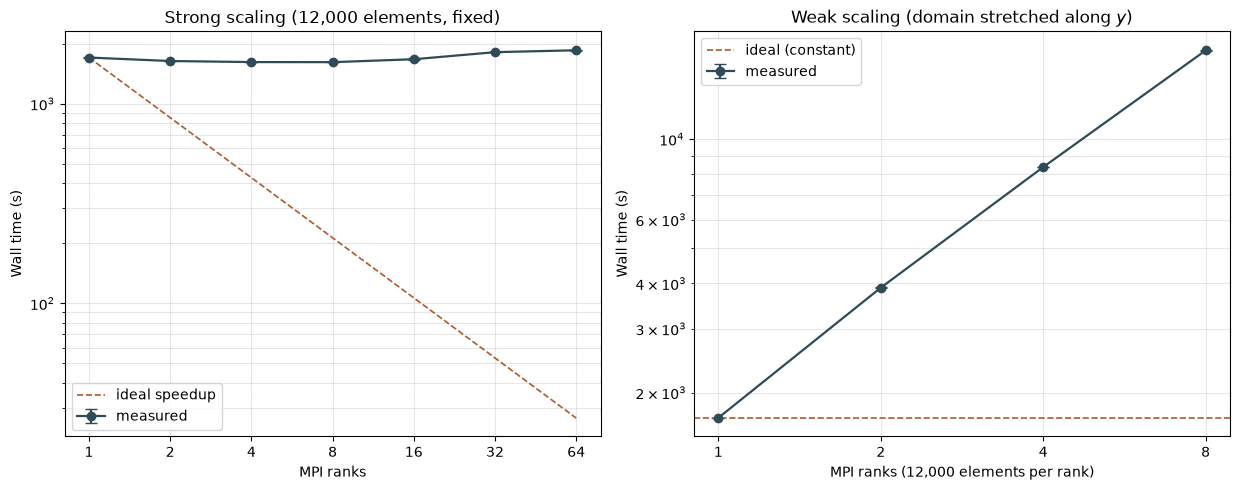

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

r = list(strong); m = [strong[k][0] for k in r]; e = [strong[k][1] for k in r]
ax1.errorbar(r, m, yerr=e, fmt='o-', color='#2f4b57', lw=1.6, ms=6, capsize=4, label='measured')
ax1.plot(r, [m[0]/k for k in r], '--', color='#b0592f', lw=1.2, label='ideal speedup')
ax1.set_xscale('log', base=2); ax1.set_yscale('log')
ax1.set_xticks(r); ax1.set_xticklabels(r)
ax1.set_xlabel('MPI ranks'); ax1.set_ylabel('Wall time (s)')
ax1.set_title('Strong scaling (12,000 elements, fixed)')
ax1.legend(); ax1.grid(alpha=0.3, which='both')

rw = list(weak); mw = [weak[k][0] for k in rw]; ew = [weak[k][1] for k in rw]
ax2.errorbar(rw, mw, yerr=ew, fmt='o-', color='#2f4b57', lw=1.6, ms=6, capsize=4, label='measured')
ax2.axhline(mw[0], ls='--', color='#b0592f', lw=1.2, label='ideal (constant)')
ax2.set_xscale('log', base=2); ax2.set_yscale('log')
ax2.set_xticks(rw); ax2.set_xticklabels(rw)
ax2.set_xlabel('MPI ranks (12,000 elements per rank)'); ax2.set_ylabel('Wall time (s)')
ax2.set_title('Weak scaling (domain stretched along $y$)')
ax2.legend(); ax2.grid(alpha=0.3, which='both')

fig.tight_layout()
fig.savefig(f"{BASE_FIG_DIR}/scaling_kgd.png", dpi=300, bbox_inches='tight')
plt.show()